Analysation of the data coming from the simulator.

In [3]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

Text(0.5, 0, 'Radio Unit')

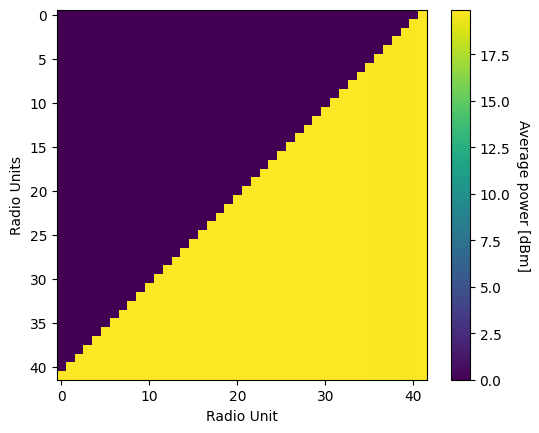

In [4]:
def pavg_dbm(data):
    pavg = np.mean(np.abs(data) ** 2)
    pavg = 10 * np.log10(pavg / 1e-3)

    return pavg

ue_ds = xr.load_dataset("configurations/ue_locations_5681.nc")

user = ue_ds.where(ue_ds["user_id"] == 0, drop=True)
x = float(user["x"])
y = float(user["y"])
z = float(user["z"])

# Read in the data for UEx
df = pd.read_pickle(f"simulations/flickering_data_0.pkl")

fig, ax = plt.subplots()
radio_units = len(df["ru_id"].unique())
data = np.zeros((radio_units, radio_units))
for ru_id in range(radio_units):
    stripe_data = df.loc[(df["stripe_id"] == 0) & (df["ru_id"] == ru_id)]
    stripe_data = stripe_data["data"].to_numpy()[0]

    #data[ru_id][-1] = pavg_dbm(stripe_data[0])

    for i, x in enumerate(stripe_data[5::4]):
        data[ru_id][radio_units - i - 1] = pavg_dbm(x)

im = ax.imshow(data)

# Create colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Average power [dBm]", rotation=-90, va="bottom")

ax.set_ylabel("Radio Units")
ax.set_xlabel("Radio Unit")